<a href="https://colab.research.google.com/github/dimashann/credit-default-prediction/blob/main/Credit_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS Prediksi Modern & Machine Learning
## Experiment Challenge: Credit Default Prediction

**Nama:** Dimas Hanif Ahmadani  
**NIM:** 2404220027

**Tujuan.** Membangun model klasifikasi biner untuk memprediksi apakah nasabah kartu kredit akan **default** (gagal bayar) pada bulan berikutnya, lalu membandingkan bagaimana *data preparation, preprocessing, pemilihan model, hyperparameter tuning,* dan *model advanced* memengaruhi performa.

**Dataset.** Default of Credit Card Clients (UCI via Kaggle), 30.000 observasi, target `default.payment.next.month` (0 = tidak default, 1 = default).


---
# 1. Setup

Memasang library tambahan (`kagglehub` untuk mengunduh dataset, `xgboost` untuk Experiment 5), mengimpor semua library yang dibutuhkan sekali di awal, dan menetapkan `RANDOM_STATE = 42`

In [ ]:
!pip install -q kagglehub xgboost

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
print("Library siap.")

Library siap.


## Membaca dataset (raw)

Mengunduh dataset dari Kaggle memakai `kagglehub` lalu membaca `UCI_Credit_Card.csv` ke DataFrame `df`. Sesuai instruksi, dataset yang dipakai adalah **raw dataset** tanpa modifikasi apa pun.

In [ ]:
CSV_NAME = "UCI_Credit_Card.csv"
try:
    import kagglehub
    path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
    print("Folder dataset:", path, "->", os.listdir(path))
    csv_path = os.path.join(path, CSV_NAME)
except Exception as e:
    print("Unduhan otomatis gagal:", e)
    if os.path.exists(CSV_NAME):
        csv_path = CSV_NAME
    else:
        from google.colab import files
        print("Silakan unggah file UCI_Credit_Card.csv")
        files.upload()
        csv_path = CSV_NAME

df = pd.read_csv(csv_path)
df.head()

100%|██████████| 0.98M/0.98M [00:00<00:00, 36.2MB/s]

Extracting files...
Folder dataset: /root/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1 -> ['UCI_Credit_Card.csv']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


**Hasil Pembacaan dataset**

Dataset berhasil diunduh dari Kaggle (`UCI_Credit_Card.csv`) dan terbaca ke dalam DataFrame. Lima baris pertama menunjukkan struktur data sesuai kamus data: identitas nasabah (`ID`), karakteristik demografis (`SEX`, `EDUCATION`, `MARRIAGE`, `AGE`), batas kredit (`LIMIT_BAL`), riwayat pembayaran (`PAY_*`), jumlah tagihan (`BILL_AMT*`), jumlah pembayaran (`PAY_AMT*`), dan target `default.payment.next.month`.

---
# 2. Experiment 0: Data Understanding & Preparation

Bagian ini melakukan:
membaca dataset, dimensi, struktur dan tipe data, variabel target, missing value, duplicate, nilai tidak wajar, distribusi target, predictor dan target, mengeluarkan ID, train-test split, preprocessing.

## 2.1 Dimensi, struktur, dan tipe data

Menampilkan jumlah baris dan kolom, tipe data tiap kolom (`info()`), dan statistik deskriptif (`describe()`). Dari sini kita tahu skala tiap fitur; skala yang timpang (misal `BILL_AMT` ratusan ribu vs `PAY_*` bernilai kecil) akan menjadi dasar keputusan *feature scaling* di Experiment 2.

In [ ]:
print("Dimensi dataset (baris, kolom):", df.shape)
print()
df.info()
print()
print("Jumlah kolom per tipe data:")
print(df.dtypes.value_counts())
df.describe().T

Dimensi dataset (baris, kolom): (30000, 25)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null 

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


**Analisis Hasil Dimensi, struktur, dan tipe data**

- Dataset terdiri dari 30.000 observasi dan 25 kolom (23 predictor, 1 kolom `ID`, 1 target), sesuai deskripsi soal.
- Seluruh kolom non-null dan bertipe numerik (13 `float64`, 12 `int64`), sehingga tidak diperlukan konversi tipe data.
- Ringkasan `describe()` menunjukkan skala antarfitur sangat timpang: `LIMIT_BAL` memiliki simpangan baku sekitar 129.748 dan `BILL_AMT` puluhan ribu, sedangkan `PAY_*` hanya sekitar 1,1. Ketimpangan ini menjadi dasar penggunaan *feature scaling* pada Experiment 2.
- Beberapa kolom nominal memuat nilai di luar dokumentasi (`EDUCATION` bernilai 0 sampai 6 dan `MARRIAGE` bernilai 0), yang diperiksa lebih lanjut pada pemeriksaan nilai tidak wajar.
- Nilai maksimum `BILL_AMT` dan `PAY_AMT` jauh di atas median (misalnya `PAY_AMT2` maksimum 1.684.259 dengan median 2.009), menandakan distribusi sangat miring ke kanan. Nilai ini dianggap perilaku nasabah yang nyata sehingga tidak dihapus.

## 2.2 Identifikasi variabel target

Memastikan kolom target ada, dan melihat nilai uniknya. Target bernilai {0, 1}, sehingga ini adalah masalah klasifikasi biner.

In [ ]:
target = "default.payment.next.month"
print("Kolom target ada di dataset:", target in df.columns)
print("Nilai unik target:", sorted(df[target].unique()))

Kolom target ada di dataset: True
Nilai unik target: [np.int64(0), np.int64(1)]


**Analisis Hasil Variabel target**

Kolom `default.payment.next.month` tersedia dan hanya bernilai {0, 1}, sehingga permasalahan ini adalah klasifikasi biner (0 = tidak default, 1 = default). (Tampilan `np.int64(...)` hanyalah representasi tipe data NumPy, bukan nilai yang berbeda.)

## 2.3 Missing value dan duplicate

Menghitung total missing value, mengecek apakah `ID` unik, dan menghitung duplikat dua cara: (a) semua kolom termasuk `ID`, (b) setelah `ID` dibuang. Cara (b) penting karena `ID` selalu berbeda sehingga duplikat sebenarnya tersembunyi.

In [ ]:
print("Total missing value :", int(df.isnull().sum().sum()))
print("ID unik semua       :", df["ID"].is_unique)
n_dup_all = int(df.duplicated().sum())
n_dup_noid = int(df.drop(columns="ID").duplicated().sum())
print("Duplikat (semua kolom)      :", n_dup_all)
print("Duplikat (setelah ID dibuang):", n_dup_noid)

Total missing value : 0
ID unik semua       : True
Duplikat (semua kolom)      : 0
Duplikat (setelah ID dibuang): 35


**Analisis Hasil Missing value dan duplikat**

- Tidak ada missing value (0), sehingga imputasi tidak diperlukan.
- `ID` bersifat unik dan tidak ada duplikat pada seluruh kolom (0).
- Setelah `ID` dikeluarkan, ditemukan 35 baris dengan profil yang identik (sekitar 0,12% dari data). Baris tersebut tidak dihapus karena `ID` yang berbeda menunjukkan nasabah yang berbeda, jumlahnya sangat kecil sehingga dampaknya terhadap model dapat diabaikan, dan soal meminta penggunaan raw dataset.

## 2.4 Nilai yang tidak sesuai atau tidak wajar

Memeriksa nilai kolom kategorikal terhadap dokumentasi dataset (SEX 1-2, EDUCATION 1-4, MARRIAGE 1-3), nilai `PAY_*`, nilai negatif pada tagihan/pembayaran, serta rentang `AGE` dan `LIMIT_BAL`.

In [ ]:
cat_cols    = ["SEX", "EDUCATION", "MARRIAGE"]
pay_cols    = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols   = [f"BILL_AMT{i}" for i in range(1, 7)]
payamt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

for c in cat_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts().sort_index().to_string(), "\n")

print("Sebaran nilai PAY_* (baris = nilai, kolom = bulan):")
print(pd.DataFrame({c: df[c].value_counts() for c in pay_cols}).sort_index().fillna(0).astype(int).to_string(), "\n")

print("BILL_AMT negatif per kolom:")
print((df[bill_cols] < 0).sum().to_string(), "\n")
print("Total PAY_AMT negatif:", int((df[payamt_cols] < 0).sum().sum()))
print("Rentang AGE      :", df["AGE"].min(), "-", df["AGE"].max())
print("Rentang LIMIT_BAL:", df["LIMIT_BAL"].min(), "-", df["LIMIT_BAL"].max())

n_edu_bad = int((~df["EDUCATION"].isin([1, 2, 3, 4])).sum())
n_mar_bad = int((~df["MARRIAGE"].isin([1, 2, 3])).sum())
print(f"\nBaris EDUCATION di luar 1-4: {n_edu_bad} | baris MARRIAGE di luar 1-3: {n_mar_bad}")

--- SEX ---
SEX
1    11888
2    18112 

--- EDUCATION ---
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51 

--- MARRIAGE ---
MARRIAGE
0       54
1    13659
2    15964
3      323 

Sebaran nilai PAY_* (baris = nilai, kolom = bulan):
    PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6
-2   2759   3782   4085   4348   4546   4895
-1   5686   6050   5938   5687   5539   5740
 0  14737  15730  15764  16455  16947  16286
 1   3688     28      4      2      0      0
 2   2667   3927   3819   3159   2626   2766
 3    322    326    240    180    178    184
 4     76     99     76     69     84     49
 5     26     25     21     35     17     13
 6     11     12     23      5      4     19
 7      9     20     27     58     58     46
 8     19      1      3      2      1      2 

BILL_AMT negatif per kolom:
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688 

Total PAY_AMT negatif: 0
Rentang AGE      : 21 - 79
Ren

**Analisis Hasil Nilai tidak sesuai atau tidak wajar**

| Variabel | Temuan | Keputusan |
|---|---|---|
| `EDUCATION` | Terdapat nilai 0 (14 baris), 5 (280), dan 6 (51) yang tidak ada di dokumentasi (hanya 1 sampai 4); total **345 baris** | Digabung ke kategori "lainnya" (4) |
| `MARRIAGE` | Terdapat nilai 0 sebanyak **54 baris** (dokumentasi hanya 1 sampai 3) | Digabung ke kategori "lainnya" (3) |
| `PAY_0` sampai `PAY_6` | Memuat nilai -2, -1, 0 yang tidak sepenuhnya terdokumentasi; nilai 1 banyak pada `PAY_0` (3.688) tetapi hampir tidak ada pada `PAY_2` sampai `PAY_6` | Dipertahankan sebagai fitur numerik ordinal karena makin besar nilainya makin lama keterlambatan |
| `BILL_AMT1` sampai `6` | Bernilai negatif sekitar 590 sampai 688 baris per kolom (sekitar 2%) | Dianggap wajar (kelebihan bayar), tidak dihapus |
| `PAY_AMT*` | Tidak ada nilai negatif | Tidak perlu tindakan |
| `AGE` dan `LIMIT_BAL` | Rentang 21 sampai 79 tahun dan 10.000 sampai 1.000.000 | Wajar |

`SEX` hanya bernilai 1 (11.888) dan 2 (18.112) sehingga sesuai dokumentasi.

## 2.5 Distribusi variabel target

Menghitung jumlah dan persentase tiap kelas target, serta menampilkan grafiknya. Ketidakseimbangan kelas menentukan dua keputusan: F1 dipakai sebagai metrik utama (bukan Accuracy), dan split dibuat stratified.

                            jumlah  persen
default.payment.next.month                
0                            23364   77.88
1                             6636   22.12

Bila model selalu menebak 'tidak default', Accuracy = 0.7788 tapi Recall = 0.


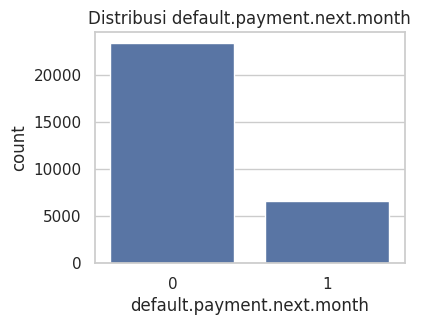

In [ ]:
vc = df[target].value_counts().sort_index()
pct = (df[target].value_counts(normalize=True).sort_index() * 100).round(2)
print(pd.DataFrame({"jumlah": vc, "persen": pct}))
default_rate = df[target].mean()
print(f"\nBila model selalu menebak 'tidak default', Accuracy = {1 - default_rate:.4f} tapi Recall = 0.")

fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(x=target, data=df, ax=ax)
ax.set_title("Distribusi default.payment.next.month")
plt.show()

**Analisis Hasil Distribusi target**

Sebanyak **77,88% nasabah tidak default** (23.364) dan **22,12% default** (6.636). Data **tidak seimbang** (rasio sekitar 3,5 : 1). Dampaknya:

1. Model yang selalu menebak "tidak default" sudah memperoleh Accuracy 0,7788 dengan Recall 0. Accuracy yang tinggi karena itu tidak cukup untuk menilai model, maka F1-score dijadikan metrik utama.
2. Pembagian data dilakukan secara stratified agar proporsi kelas terjaga di data latih dan data uji.

## 2.6 Eksplorasi tambahan (distribusi dan korelasi)

Histogram `LIMIT_BAL` dan `AGE`, serta korelasi tiap fitur dengan target. Ini membantu menjelaskan fitur mana yang paling informatif (biasanya `PAY_0` dan `PAY_*` lain).

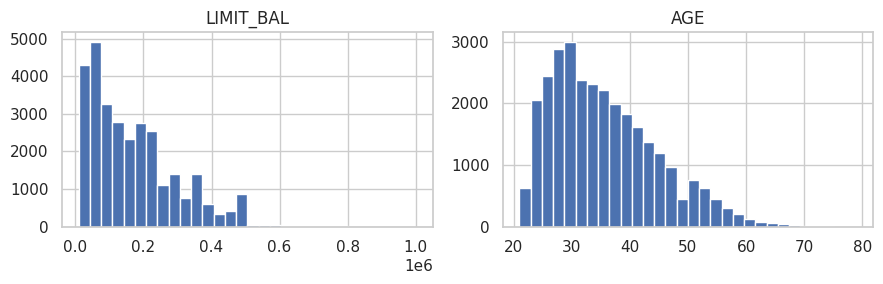

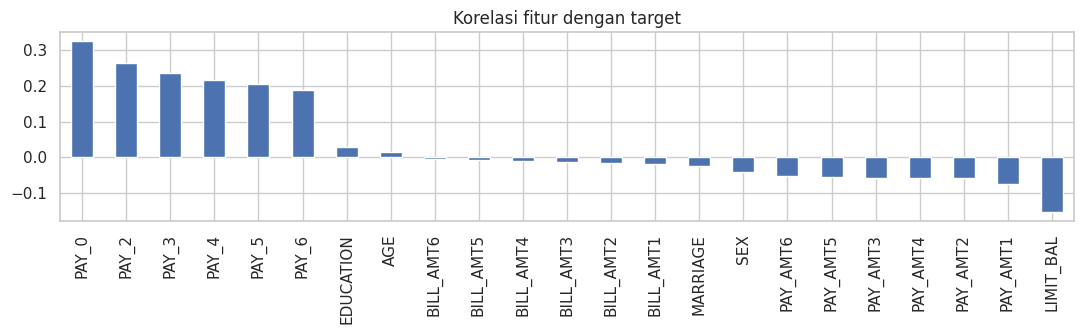

Korelasi positif tertinggi: {'PAY_0': 0.325, 'PAY_2': 0.264, 'PAY_3': 0.235}
Korelasi negatif terendah : {'PAY_AMT2': -0.059, 'PAY_AMT1': -0.073, 'LIMIT_BAL': -0.154}


In [ ]:
df[["LIMIT_BAL", "AGE"]].hist(bins=30, figsize=(9, 3))
plt.tight_layout(); plt.show()

corr_target = df.drop(columns="ID").corr()[target].drop(target).sort_values(ascending=False)
corr_target.plot.bar(figsize=(11, 3.5), title="Korelasi fitur dengan target")
plt.tight_layout(); plt.show()
print("Korelasi positif tertinggi:", corr_target.head(3).round(3).to_dict())
print("Korelasi negatif terendah :", corr_target.tail(3).round(3).to_dict())

**Analisis Hasil Eksplorasi distribusi dan korelasi**

- Histogram `LIMIT_BAL` dan `AGE` miring ke kanan: sebagian besar nasabah memiliki limit rendah sampai menengah dan berusia sekitar 25 sampai 40 tahun.
- Fitur dengan korelasi positif tertinggi terhadap target adalah `PAY_0` (0,325), lalu `PAY_2` (0,264) dan `PAY_3` (0,235): nasabah yang sering terlambat membayar lebih mungkin default. Korelasi negatif terkuat adalah `LIMIT_BAL` (-0,154): makin besar limit kredit, makin kecil kecenderungan default.
- Korelasi tertinggi hanya sekitar 0,33, artinya tidak ada satu fitur yang sangat dominan. Ini mengindikasikan bahwa masalah prediksi ini tidak mudah sehingga nilai F1 yang sangat tinggi tidak dapat diharapkan.

## 2.7 Ringkasan temuan Data Understanding (otomatis)


In [ ]:
print("TEMUAN DATA UNDERSTANDING")
print(f"1. Dataset berisi {df.shape[0]:,} baris dan {df.shape[1]} kolom; seluruh kolom bertipe numerik.")
print(f"2. Missing value: {int(df.isnull().sum().sum())}.")
print(f"3. Duplikat: {n_dup_all} (semua kolom) dan {n_dup_noid} setelah ID dibuang.")
print(f"4. Nilai tidak sesuai dokumentasi: EDUCATION di luar 1-4 = {n_edu_bad} baris, MARRIAGE di luar 1-3 = {n_mar_bad} baris.")
print("5. PAY_* memuat nilai -2, -1, 0 yang tidak sepenuhnya terdokumentasi; dipertahankan karena urutannya bermakna (makin besar makin telat).")
print("6. BILL_AMT bernilai negatif dianggap wajar (kelebihan bayar), tidak dihapus.")
print(f"7. Target tidak seimbang: {default_rate*100:.2f}% default vs {(1-default_rate)*100:.2f}% tidak default.")
print("8. Skala fitur sangat timpang (LIMIT_BAL/BILL_AMT jauh lebih besar dari PAY_*), jadi feature scaling relevan untuk Logistic Regression.")

TEMUAN DATA UNDERSTANDING
1. Dataset berisi 30,000 baris dan 25 kolom; seluruh kolom bertipe numerik.
2. Missing value: 0.
3. Duplikat: 0 (semua kolom) dan 35 setelah ID dibuang.
4. Nilai tidak sesuai dokumentasi: EDUCATION di luar 1-4 = 345 baris, MARRIAGE di luar 1-3 = 54 baris.
5. PAY_* memuat nilai -2, -1, 0 yang tidak sepenuhnya terdokumentasi; dipertahankan karena urutannya bermakna (makin besar makin telat).
6. BILL_AMT bernilai negatif dianggap wajar (kelebihan bayar), tidak dihapus.
7. Target tidak seimbang: 22.12% default vs 77.88% tidak default.
8. Skala fitur sangat timpang (LIMIT_BAL/BILL_AMT jauh lebih besar dari PAY_*), jadi feature scaling relevan untuk Logistic Regression.


## 2.8 Data Preparation membersihkan nilai tidak sesuai

**Keputusan:** nilai `EDUCATION` 0, 5, 6 dan `MARRIAGE` 0 tidak ada di dokumentasi, jadi digabung ke kategori "lainnya" (EDUCATION = 4, MARRIAGE = 3). Baris tidak dibuang agar tidak kehilangan data. Pemetaan ini adalah aturan tetap (tidak mempelajari statistik apa pun dari data), sehingga aman dari data leakage walaupun dilakukan sebelum split.

**Duplikat:** tidak dihapus. Karena `ID` berbeda, baris kembar itu bisa jadi nasabah berbeda dengan profil sama; jumlahnya kecil, dan instruksi meminta memakai raw dataset.

In [ ]:
df_clean = df.copy()
df_clean["EDUCATION"] = df_clean["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df_clean["MARRIAGE"]  = df_clean["MARRIAGE"].replace({0: 3})

print("EDUCATION setelah dibersihkan:\n", df_clean["EDUCATION"].value_counts().sort_index().to_string(), "\n")
print("MARRIAGE setelah dibersihkan:\n", df_clean["MARRIAGE"].value_counts().sort_index().to_string())

EDUCATION setelah dibersihkan:
 EDUCATION
1    10585
2    14030
3     4917
4      468 

MARRIAGE setelah dibersihkan:
 MARRIAGE
1    13659
2    15964
3      377


**Analisis Hasil Pembersihan EDUCATION dan MARRIAGE**

Setelah pembersihan, `EDUCATION` hanya bernilai 1 sampai 4 (kategori 4 menjadi 468 baris = 123 + 14 + 280 + 51) dan `MARRIAGE` hanya 1 sampai 3 (kategori 3 menjadi 377 baris = 323 + 54). Jumlah baris tetap 30.000, sehingga tidak ada data yang hilang. Aturan pemetaan ini bersifat tetap (tidak mempelajari statistik dari data), sehingga tidak menimbulkan data leakage.

## 2.9 Menentukan predictor dan target, mengeluarkan ID

`y` = kolom target; `X` = semua kolom lain kecuali `ID` (hanya pengenal, tidak punya makna prediktif) dan kecuali target. `assert` memastikan tidak ada kebocoran target atau ID ke predictor.

In [ ]:
X = df_clean.drop(columns=["ID", target])
y = df_clean[target]

assert "ID" not in X.columns and target not in X.columns
print("Jumlah predictor:", X.shape[1], "| Jumlah observasi:", X.shape[0])
print(list(X.columns))

Jumlah predictor: 23 | Jumlah observasi: 30000
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## 2.10 Train-test split

Membagi data 80% train dan 20% test dengan `stratify=y` (proporsi default sama di kedua bagian) dan `random_state=42`. Split dilakukan sebelum semua training dan sebelum scaling/encoding apa pun. Test set tidak dipakai untuk memilih model atau tuning, hanya untuk evaluasi akhir tiap model.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporsi default - train:", round(y_train.mean(), 4), "| test:", round(y_test.mean(), 4))

Train: (24000, 23) | Test: (6000, 23)
Proporsi default - train: 0.2212 | test: 0.2212


**Analisis Hasil Predictor, target, dan train-test split**

- Terdapat 23 predictor (20 numerik dan 3 kategorikal nominal); `ID` dan target sudah dikeluarkan dari predictor.
- Data terbagi menjadi 24.000 baris latih dan 6.000 baris uji. Proporsi default sama persis di kedua bagian (0,2212), yang menunjukkan *stratified split* berjalan benar.
- Test set tidak digunakan untuk memilih model maupun tuning, sehingga hasil evaluasinya mewakili performa pada data baru.

## 2.11 Menyiapkan 5-fold Cross Validation dan kelompok kolom

Membuat satu objek `cv` (Stratified 5-fold, shuffle, seed tetap) yang dipakai di semua eksperimen sehingga prosedur evaluasi identik antar model. Juga memisahkan kolom numerik dan kategorikal untuk preprocessing di Experiment 2.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
num_cols = [c for c in X.columns if c not in cat_cols]
print(f"{len(num_cols)} kolom numerik | {len(cat_cols)} kolom kategorikal nominal: {cat_cols}")

20 kolom numerik | 3 kolom kategorikal nominal: ['SEX', 'EDUCATION', 'MARRIAGE']


## 2.12 Keputusan preprocessing pada Experiment 0

- Dilakukan: pembersihan EDUCATION/MARRIAGE, pembuangan `ID`, split stratified.
- Tidak ada missing value (lihat 2.3), jadi imputasi tidak diperlukan.
- Outlier tidak dibuang: tagihan/pembayaran besar adalah perilaku nasabah yang nyata, bukan kesalahan input.
- Scaling dan encoding sengaja belum dilakukan di sini. Keduanya baru diterapkan di Experiment 2 melalui `Pipeline`, agar (1) Experiment 1 benar-benar menjadi baseline, dan (2) tidak terjadi data leakage karena scaler/encoder hanya belajar dari *training fold*. Ini sesuai catatan dosen: tidak semua teknik preprocessing harus digunakan.

---
# 3. Fungsi Evaluasi (dipakai semua eksperimen)

Definisi metrik

- **Accuracy:** persentase prediksi benar. Bisa menyesatkan saat data tidak seimbang.
- **Precision:**  dari nasabah yang diprediksi default, berapa yang benar-benar default.
- **Recall:** dari nasabah yang benar-benar default, berapa yang berhasil terdeteksi.
- **F1-score:** rata-rata harmonik Precision dan Recall; metrik utama karena menyeimbangkan keduanya pada data tidak seimbang.
- **CV F1:** rata-rata F1 dari 5-fold CV pada training set (`CV_F1_std` = simpangan baku antar fold, ukuran stabilitas).

Fungsi `evaluate()` melakukan tiga hal pada setiap model: (1) 5-fold CV hanya pada training set, (2) melatih ulang model pada seluruh training set, (3) menghitung metrik pada test set. Hasil disimpan di dictionary `results`, sehingga tabel akhir otomatis sama dengan output notebook. `Train_F1` disimpan untuk mendeteksi overfitting.

In [ ]:
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1"}
results = {}
fitted = {}

def evaluate(model, name, exp, plot_cm=True):
    cvr = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    model.fit(X_train, y_train)
    pred_te = model.predict(X_test)
    pred_tr = model.predict(X_train)

    row = {
        "Experiment": exp, "Model": name,
        "CV_F1": cvr["test_f1"].mean(), "CV_F1_std": cvr["test_f1"].std(),
        "CV_Acc": cvr["test_accuracy"].mean(), "CV_Prec": cvr["test_precision"].mean(),
        "CV_Rec": cvr["test_recall"].mean(),
        "Test_Acc":  accuracy_score(y_test, pred_te),
        "Test_Prec": precision_score(y_test, pred_te, zero_division=0),
        "Test_Rec":  recall_score(y_test, pred_te),
        "Test_F1":   f1_score(y_test, pred_te),
        "Train_F1":  f1_score(y_train, pred_tr),
    }
    results[f"{exp}|{name}"] = row

    print(f"=== {name} (Experiment {exp}) ===")
    print(f"5-fold CV (train): Acc {row['CV_Acc']:.4f} | Prec {row['CV_Prec']:.4f} | "
          f"Rec {row['CV_Rec']:.4f} | F1 {row['CV_F1']:.4f} (std {row['CV_F1_std']:.4f})")
    print(f"Test set         : Acc {row['Test_Acc']:.4f} | Prec {row['Test_Prec']:.4f} | "
          f"Rec {row['Test_Rec']:.4f} | F1 {row['Test_F1']:.4f}")
    print(f"Train F1 (cek overfitting): {row['Train_F1']:.4f}")
    if plot_cm:
        ConfusionMatrixDisplay.from_predictions(y_test, pred_te)
        plt.title(f"Confusion matrix - {name}"); plt.show()
    return model

def trend(new, old, tol=0.0):
    d = new - old
    if d > tol:  return "meningkat"
    if d < -tol: return "menurun"
    return "relatif tidak berubah"

metric_cols = ["CV_F1", "Test_Acc", "Test_Prec", "Test_Rec", "Test_F1"]
print("Fungsi evaluasi siap.")

Fungsi evaluasi siap.


---
# 4. Experiment 1 — Baseline Model

Logistic Regression sebagai baseline, memakai data hasil Experiment 0 tanpa scaling dan tanpa encoding. Hasilnya menjadi pembanding semua eksperimen berikutnya.

Melatih Logistic Regression, menampilkan 5-fold CV pada training set dan evaluasi pada test set (Accuracy, Precision, Recall, F1, CV F1). Jika muncul warning konvergensi, itu wajar karena skala fitur berbeda jauh; hal ini akan dibahas di Experiment 2.

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression (baseline) (Experiment 1) ===
5-fold CV (train): Acc 0.8055 | Prec 0.6815 | Rec 0.2251 | F1 0.3367 (std 0.0493)
Test set         : Acc 0.8082 | Prec 0.6648 | Rec 0.2675 | F1 0.3815
Train F1 (cek overfitting): 0.3899


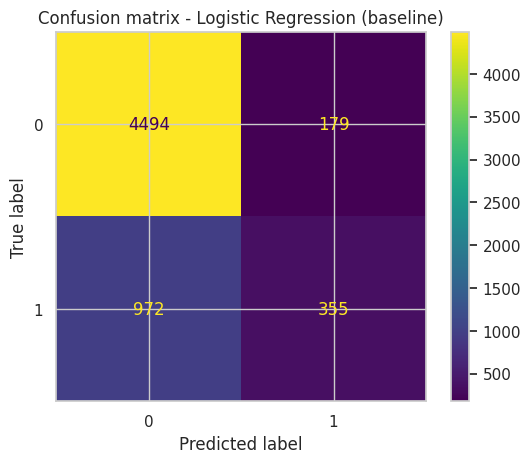

In [ ]:
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline = evaluate(baseline, "Logistic Regression (baseline)", 1)
fitted["1"] = baseline
K1 = "1|Logistic Regression (baseline)"

**Analisis Hasil Experiment 1 (Baseline Logistic Regression)**

- ConvergenceWarning muncul karena fitur belum diskalakan sehingga optimizer `lbfgs` berhenti sebelum konvergen. Ini bukan error, melainkan konsekuensi yang diperkirakan dari data mentah, dan menjadi alasan dilakukannya preprocessing pada Experiment 2.

| | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| CV 5-fold (std F1 = 0,0493) | 0,8055 | 0,6815 | 0,2251 | **0,3367** |
| Test | 0,8082 | 0,6648 | 0,2675 | **0,3815** |

- Pada *confusion matrix* test: 4.494 benar-benar tidak default terdeteksi benar, 179 salah ditandai default, 972 nasabah default terlewat, dan 355 default terdeteksi. Dari 1.327 nasabah default, baseline hanya menangkap sekitar 27%.
- Accuracy 0,81 terlihat baik tetapi hanya sekitar 3 poin di atas tebakan mayoritas (0,7788); Recall rendah menunjukkan model cenderung memprediksi "tidak default".
- Train F1 (0,3899) hampir sama dengan Test F1 (0,3815), sehingga model tidak overfitting, tetapi underfitting (sederhana dan lemah). Simpangan baku CV yang besar (0,0493) wajar karena model belum konvergen.
- Hasil ini menjadi baseline (F1 test 0,3815) untuk membandingkan eksperimen berikutnya.

In [ ]:
r = results[K1]
print("INTERPRETASI EXPERIMENT 1")
print(f"- Baseline Logistic Regression: CV F1 = {r['CV_F1']:.4f}, Test F1 = {r['Test_F1']:.4f}, "
      f"Accuracy = {r['Test_Acc']:.4f}, Precision = {r['Test_Prec']:.4f}, Recall = {r['Test_Rec']:.4f}.")
if r["Test_Acc"] > r["Test_Rec"] + 0.3:
    print(f"- Accuracy ({r['Test_Acc']:.2f}) jauh lebih tinggi daripada Recall ({r['Test_Rec']:.2f}): model "
          "cenderung memprediksi 'tidak default' (kelas mayoritas), sehingga banyak nasabah default terlewat. "
          "Inilah alasan F1, bukan Accuracy, dijadikan metrik utama.")
print(f"- Selisih Train F1 ({r['Train_F1']:.4f}) dan Test F1 ({r['Test_F1']:.4f}) = {abs(r['Train_F1']-r['Test_F1']):.4f} "
      "(kecil berarti tidak ada overfitting berarti).")
print("- Angka ini menjadi patokan untuk Experiment 2-5.")

INTERPRETASI EXPERIMENT 1
- Baseline Logistic Regression: CV F1 = 0.3367, Test F1 = 0.3815, Accuracy = 0.8082, Precision = 0.6648, Recall = 0.2675.
- Accuracy (0.81) jauh lebih tinggi daripada Recall (0.27): model cenderung memprediksi 'tidak default' (kelas mayoritas), sehingga banyak nasabah default terlewat. Inilah alasan F1, bukan Accuracy, dijadikan metrik utama.
- Selisih Train F1 (0.3899) dan Test F1 (0.3815) = 0.0084 (kecil berarti tidak ada overfitting berarti).
- Angka ini menjadi patokan untuk Experiment 2-5.


---
# 5. Experiment 2 — Preprocessing

Menerapkan preprocessing yang relevan, lalu membangun ulang Logistic Regression dan membandingkannya dengan baseline.

**Preprocessing yang dipilih dan alasannya:**

1. **StandardScaler** pada kolom numerik, fitur berskala sangat berbeda (jutaan vs satuan). Logistic Regression berbasis gradient sensitif terhadap skala, dan regularisasi menjadi adil antar fitur.
2. **One-Hot Encoding** pada `SEX`, `EDUCATION`, `MARRIAGE`, ketiganya nominal, sehingga tidak boleh diperlakukan sebagai angka berurutan. `drop="first"` menghindari multikolinearitas.
3. `PAY_*` tidak di-encode karena ordinal (makin besar makin telat) sehingga cocok tetap numerik.

Sel berikut membangun `ColumnTransformer` lalu membungkusnya dengan model dalam `Pipeline`. Dengan `Pipeline`, scaler dan encoder di-*fit* ulang hanya pada *training fold* di setiap putaran CV dan hanya pada training set saat final, inilah mekanisme yang mencegah data leakage.

=== Logistic Regression + Preprocessing (Experiment 2) ===
5-fold CV (train): Acc 0.8108 | Prec 0.7094 | Rec 0.2451 | F1 0.3641 (std 0.0151)
Test set         : Acc 0.8088 | Prec 0.6923 | Rec 0.2442 | F1 0.3610
Train F1 (cek overfitting): 0.3701


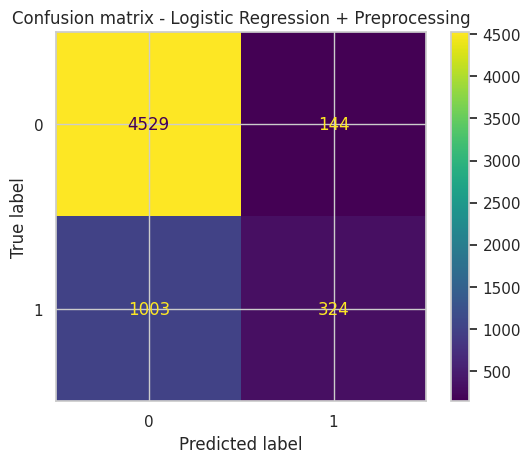

In [ ]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
])

def make_pipe(model):
    return Pipeline([("prep", clone(preprocessor)), ("model", model)])

lr_prep = evaluate(
    make_pipe(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "Logistic Regression + Preprocessing", 2)
fitted["2"] = lr_prep
K2 = "2|Logistic Regression + Preprocessing"


 Membandingkan Experiment 2 dengan baseline (Experiment 1) dan menjawab pertanyaan *"apakah preprocessing memberi peningkatan performa?"*. Aturan yang dipakai: perubahan dianggap berarti hanya jika lebih besar daripada simpangan baku CV F1 (variasi alami antar fold). Jika tidak, jawabannya "tidak ada peningkatan berarti".

In [ ]:
r1, r2 = results[K1], results[K2]
cmp12 = pd.DataFrame([r1, r2]).set_index("Model")
display(cmp12[metric_cols + ["CV_F1_std", "Train_F1"]].round(4))
print("Selisih (Experiment 2 - Experiment 1):")
display((cmp12[metric_cols].diff().iloc[[1]]).round(4))

tol = max(r1["CV_F1_std"], r2["CV_F1_std"])
d_cv, d_te = r2["CV_F1"] - r1["CV_F1"], r2["Test_F1"] - r1["Test_F1"]
print("\nINTERPRETASI EXPERIMENT 2")
print(f"- CV F1 {trend(r2['CV_F1'], r1['CV_F1'], tol)}: {r1['CV_F1']:.4f} -> {r2['CV_F1']:.4f} (selisih {d_cv:+.4f}, std CV = {tol:.4f}).")
print(f"- Test F1 {trend(r2['Test_F1'], r1['Test_F1'], 0.005)}: {r1['Test_F1']:.4f} -> {r2['Test_F1']:.4f} (selisih {d_te:+.4f}).")
print(f"- Accuracy {r1['Test_Acc']:.4f} -> {r2['Test_Acc']:.4f}; Precision {r1['Test_Prec']:.4f} -> {r2['Test_Prec']:.4f}; "
      f"Recall {r1['Test_Rec']:.4f} -> {r2['Test_Rec']:.4f}.")
if d_cv > tol and d_te > 0:
    verdict = "YA, preprocessing memberi peningkatan performa (perubahan CV F1 melebihi variasi antar fold dan didukung test set)."
elif abs(d_cv) <= tol:
    verdict = "TIDAK ada peningkatan yang berarti: perubahan F1 masih berada dalam variasi antar fold CV."
else:
    verdict = "TIDAK, preprocessing justru menurunkan F1 secara berarti."
print("- KESIMPULAN:", verdict)
print("- Catatan: walau F1 tidak berubah banyak, scaling tetap bermanfaat (konvergensi lebih stabil, koefisien dapat dibandingkan antar fitur) dan encoding menghindari anggapan urutan palsu pada SEX/EDUCATION/MARRIAGE.")

,CV_F1,Test_Acc,Test_Prec,Test_Rec,Test_F1,CV_F1_std,Train_F1
Model,,,,,,,
Logistic Regression (baseline),0.3367,0.8082,0.6648,0.2675,0.3815,0.0493,0.3899
Logistic Regression + Preprocessing,0.3641,0.8088,0.6923,0.2442,0.3610,0.0151,0.3701


Selisih (Experiment 2 - Experiment 1):


,CV_F1,Test_Acc,Test_Prec,Test_Rec,Test_F1
Model,,,,,
Logistic Regression + Preprocessing,0.0275,0.0007,0.0275,-0.0234,-0.0205



INTERPRETASI EXPERIMENT 2
- CV F1 relatif tidak berubah: 0.3367 -> 0.3641 (selisih +0.0275, std CV = 0.0493).
- Test F1 menurun: 0.3815 -> 0.3610 (selisih -0.0205).
- Accuracy 0.8082 -> 0.8088; Precision 0.6648 -> 0.6923; Recall 0.2675 -> 0.2442.
- KESIMPULAN: TIDAK ada peningkatan yang berarti: perubahan F1 masih berada dalam variasi antar fold CV.
- Catatan: walau F1 tidak berubah banyak, scaling tetap bermanfaat (konvergensi lebih stabil, koefisien dapat dibandingkan antar fitur) dan encoding menghindari anggapan urutan palsu pada SEX/EDUCATION/MARRIAGE.


**Analisis Hasil Experiment 2 (Preprocessing)**

Preprocessing yang diterapkan: *StandardScaler* pada 20 fitur numerik dan *One-Hot Encoding* pada `SEX`, `EDUCATION`, `MARRIAGE` (nominal), di dalam `Pipeline` agar tidak terjadi data leakage.

| | CV F1 (std) | Test Acc | Test Prec | Test Rec | Test F1 |
|---|---|---|---|---|---|
| Experiment 1 | 0,3367 (0,0493) | 0,8082 | 0,6648 | 0,2675 | 0,3815 |
| Experiment 2 | 0,3641 (0,0151) | 0,8088 | 0,6923 | 0,2442 | 0,3610 |
| Selisih | +0,0275 | +0,0007 | +0,0275 | -0,0234 | -0,0205 |

- Preprocessing tidak memberikan peningkatan F1 yang berarti. CV F1 naik 0,0275 tetapi Test F1 turun 0,0205; keduanya berlawanan arah dan lebih kecil daripada variasi antar fold (std 0,0493), sehingga performa kedua model dapat dianggap setara.
- Precision naik (0,6648 menjadi 0,6923) sedangkan Recall turun (0,2675 menjadi 0,2442): model menjadi sedikit lebih konservatif dalam menandai default.
- Manfaat nyata preprocessing adalah stabilitas: simpangan baku CV turun dari 0,0493 menjadi 0,0151 dan warning konvergensi hilang. Hal ini wajar karena Logistic Regression pada dasarnya tidak banyak berubah akurasinya setelah konvergen; scaling terutama membantu proses optimasi.

**Eksperimen tambahan: penanganan ketidakseimbangan kelas.** Kalau Recall pada Experiment 2 masih rendah, `class_weight="balanced"` dapat menaikkan Recall dengan mengorbankan Precision. Hasil ini diberi label "2b" dan tidak masuk tabel ringkasan resmi (supaya tabel tetap sesuai definisi Experiment 2 dari dosen); gunakan hanya sebagai bahan pembahasan.

=== Logistic Regression + Preprocessing + class_weight balanced (Experiment 2b) ===
5-fold CV (train): Acc 0.6895 | Prec 0.3818 | Rec 0.6510 | F1 0.4812 (std 0.0119)
Test set         : Acc 0.6787 | Prec 0.3679 | Rec 0.6307 | F1 0.4647
Train F1 (cek overfitting): 0.4835


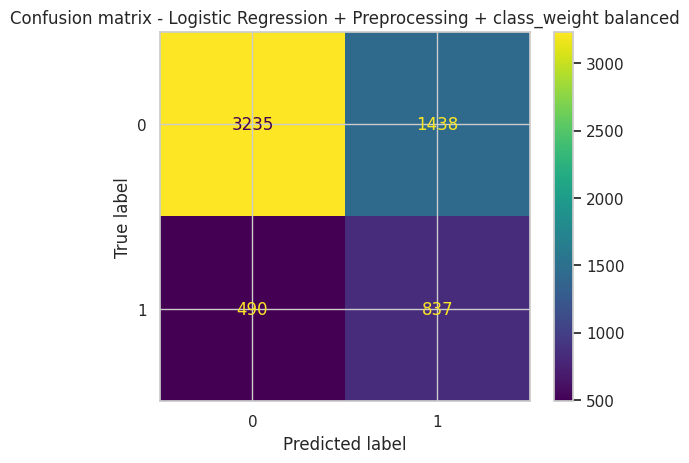

In [ ]:
lr_bal = evaluate(
    make_pipe(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    "Logistic Regression + Preprocessing + class_weight balanced", "2b")

**Analisis Hasil Experiment 2b (tambahan: `class_weight='balanced'`)**

Eksperimen tambahan ini tidak masuk tabel resmi. Dengan memberi bobot lebih pada kelas minoritas, CV F1 naik menjadi 0,4812 dan Test F1 0,4647 (dari 0,3610), dengan Recall naik menjadi 0,6307. Sebagai konsekuensinya Accuracy turun menjadi 0,6787 dan Precision menjadi 0,3679. Temuan ini menunjukkan bahwa penanganan ketidakseimbangan kelas memberi dampak yang jauh lebih besar terhadap F1 daripada scaling/encoding, dan menjadi petunjuk untuk interpretasi hasil tuning di Experiment 4.

---
# 6. Experiment 3 — Model Comparison

Tujuannya unntuk membandingkan Logistic Regression, Decision Tree, dan Random Forest dengan prosedur evaluasi yang sama persis (pipeline preprocessing yang sama, `cv` yang sama, fungsi `evaluate` yang sama).


=== Logistic Regression (Experiment 3) ===
5-fold CV (train): Acc 0.8108 | Prec 0.7094 | Rec 0.2451 | F1 0.3641 (std 0.0151)
Test set         : Acc 0.8088 | Prec 0.6923 | Rec 0.2442 | F1 0.3610
Train F1 (cek overfitting): 0.3701


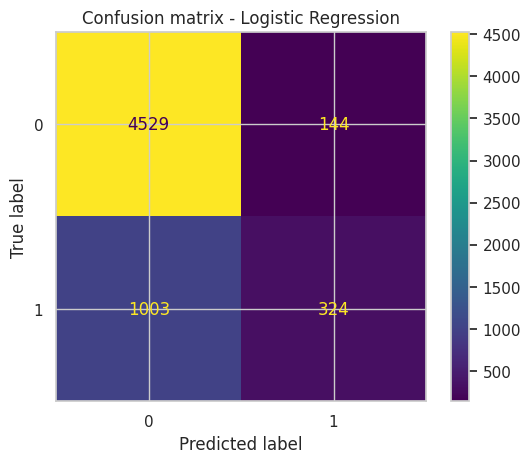

=== Decision Tree (Experiment 3) ===
5-fold CV (train): Acc 0.7255 | Prec 0.3868 | Rec 0.4116 | F1 0.3988 (std 0.0117)
Test set         : Acc 0.7208 | Prec 0.3771 | Rec 0.4024 | F1 0.3894
Train F1 (cek overfitting): 0.9988


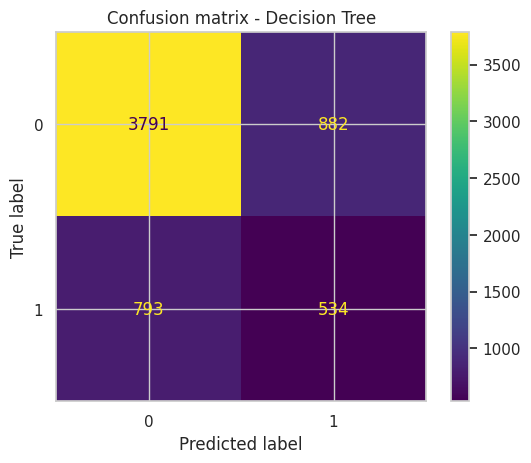

=== Random Forest (Experiment 3) ===
5-fold CV (train): Acc 0.8179 | Prec 0.6531 | Rec 0.3771 | F1 0.4781 (std 0.0064)
Test set         : Acc 0.8113 | Prec 0.6275 | Rec 0.3617 | F1 0.4589
Train F1 (cek overfitting): 0.9988


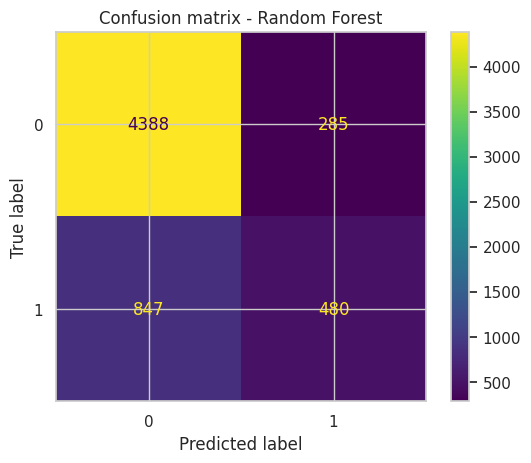

In [ ]:
models3 = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}
fitted3 = {}
for name, m in models3.items():
    fitted3[name] = evaluate(make_pipe(m), name, 3)

Menyusun tabel perbandingan (CV F1, Test Accuracy, Precision, Recall, F1), membuat grafiknya, lalu menentukan model terbaik berdasarkan CV F1. CV F1 dipakai sebagai kriteria karena dihitung dari 5 lipatan *training set* (lebih stabil dan tidak menyentuh test set); Test F1 dipakai untuk memverifikasi konsistensi. Variabel `best3` otomatis dipakai di Experiment 4. Sesuai instruksi, pemenang ditentukan oleh hasil, bukan asumsi.

,CV_F1,Test_Acc,Test_Prec,Test_Rec,Test_F1,CV_F1_std,Train_F1
Model,,,,,,,
Random Forest,0.4781,0.8113,0.6275,0.3617,0.4589,0.0064,0.9988
Decision Tree,0.3988,0.7208,0.3771,0.4024,0.3894,0.0117,0.9988
Logistic Regression,0.3641,0.8088,0.6923,0.2442,0.3610,0.0151,0.3701


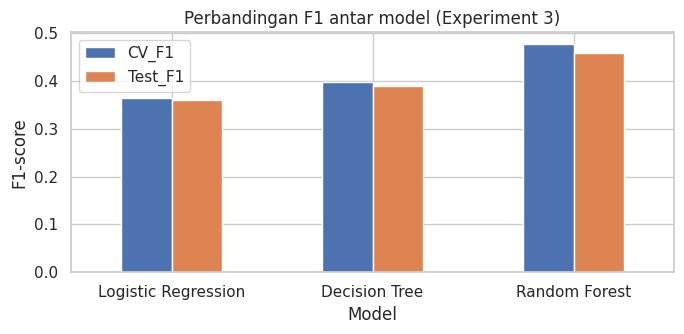

INTERPRETASI EXPERIMENT 3
- Model terbaik berdasarkan CV F1: Random Forest (CV F1 = 0.4781 +/- 0.0064).
- Model terbaik berdasarkan Test F1: Random Forest (Test F1 = 0.4589).
- Kedua kriteria konsisten.
- Logistic Regression: Train F1 0.3701 vs Test F1 0.3610 (gap 0.0091) -> gap train-test wajar.
- Decision Tree: Train F1 0.9988 vs Test F1 0.3894 (gap 0.6094) -> indikasi OVERFITTING.
- Random Forest: Train F1 0.9988 vs Test F1 0.4589 (gap 0.5399) -> indikasi OVERFITTING.

>>> Model yang dibawa ke Experiment 4: Random Forest


In [ ]:
comp3 = pd.DataFrame([results[f"3|{n}"] for n in models3]).set_index("Model")
display(comp3[metric_cols + ["CV_F1_std", "Train_F1"]].sort_values("CV_F1", ascending=False).round(4))

comp3[["CV_F1", "Test_F1"]].plot.bar(figsize=(7, 3.5), title="Perbandingan F1 antar model (Experiment 3)")
plt.ylabel("F1-score"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

best3 = comp3["CV_F1"].idxmax()
best3_test = comp3["Test_F1"].idxmax()
fitted["3"] = fitted3[best3]

print("INTERPRETASI EXPERIMENT 3")
print(f"- Model terbaik berdasarkan CV F1: {best3} (CV F1 = {comp3.loc[best3,'CV_F1']:.4f} +/- {comp3.loc[best3,'CV_F1_std']:.4f}).")
print(f"- Model terbaik berdasarkan Test F1: {best3_test} (Test F1 = {comp3.loc[best3_test,'Test_F1']:.4f}).")
print("- Kedua kriteria konsisten." if best3 == best3_test else
      "- CV dan test set menunjuk model berbeda; model dipilih berdasarkan CV karena dihitung dari 5 lipatan dan tidak memakai test set.")
for n in comp3.index:
    gap = comp3.loc[n, "Train_F1"] - comp3.loc[n, "Test_F1"]
    flag = "indikasi OVERFITTING" if gap > 0.15 else "gap train-test wajar"
    print(f"- {n}: Train F1 {comp3.loc[n,'Train_F1']:.4f} vs Test F1 {comp3.loc[n,'Test_F1']:.4f} (gap {gap:.4f}) -> {flag}.")
print(f"\n>>> Model yang dibawa ke Experiment 4: {best3}")

**Analisis Hasil Experiment 3 (Model Comparison)**

| Model | CV F1 (std) | Test Acc | Test Prec | Test Rec | Test F1 | Train F1 |
|---|---|---|---|---|---|---|
| Logistic Regression | 0,3641 (0,0151) | 0,8088 | 0,6923 | 0,2442 | 0,3610 | 0,3701 |
| Decision Tree | 0,3988 (0,0117) | 0,7208 | 0,3771 | 0,4024 | 0,3894 | 0,9988 |
| **Random Forest** | **0,4781 (0,0064)** | 0,8113 | 0,6275 | 0,3617 | **0,4589** | 0,9988 |

- Random Forest memberikan performa terbaik sebelum tuning, baik berdasarkan CV F1 (0,4781) maupun Test F1 (0,4589). Kedua kriteria konsisten, dan simpangan baku CV-nya paling kecil (0,0064) sehingga hasilnya stabil. Model ini dibawa ke Experiment 4.
- Baris Logistic Regression identik dengan Experiment 2 karena memakai pipeline dan prosedur evaluasi yang sama.
- Decision Tree dan Random Forest mengalami overfitting (Train F1 0,9988 vs Test F1 0,3894 dan 0,4589) karena tumbuh tanpa batas kedalaman sehingga menghafal data latih. Random Forest tetap lebih baik karena rata-rata banyak pohon meredam variansi.
- Logistic Regression tidak overfit (gap 0,009) tetapi kapasitasnya terbatas untuk pola nonlinier, sehingga F1-nya terendah.
- Accuracy tidak mencerminkan peringkat yang sebenarnya (Decision Tree memiliki Accuracy terendah, 0,7208), yang menguatkan penggunaan F1 sebagai metrik utama.

---
# 7. Experiment 4 — Hyperparameter Tuning

**Tujuan:** menyetel hyperparameter model terbaik dari Experiment 3 (`best3`) dengan **GridSearchCV** + **5-fold CV** (memakai objek `cv` yang sama), dengan `scoring="f1"` agar tuning mengoptimalkan metrik utama.

**Hyperparameter yang diuji dan fungsinya**

| Hyperparameter | Fungsi |
|---|---|
| `C` (Logistic Regression) | Kebalikan kekuatan regularisasi; makin kecil makin kuat, mengurangi overfitting |
| `penalty` | Jenis regularisasi: L1 (menolkan fitur tak penting) atau L2 |
| `max_depth` (Tree/Forest) | Kedalaman maksimum pohon; membatasi kompleksitas |
| `min_samples_leaf` | Minimal sampel per daun; makin besar makin halus, mengurangi overfitting |
| `criterion` | Ukuran kualitas pemisahan (gini / entropy) |
| `n_estimators` (Forest) | Jumlah pohon |
| `class_weight` | `balanced` memberi bobot lebih ke kelas minoritas (default) sehingga Recall naik |

In [ ]:
param_grids = {
    "Logistic Regression": {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__class_weight": [None, "balanced"],
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_leaf": [1, 10, 50],
        "model__criterion": ["gini", "entropy"],
        "model__class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, None],
        "model__min_samples_leaf": [1, 5],
        "model__class_weight": [None, "balanced"],
    },
}
grid_space = param_grids[best3]
n_comb = int(np.prod([len(v) for v in grid_space.values()]))
print(f"Model yang disetel : {best3}")
print(f"Hyperparameter yang diuji: {grid_space}")
print(f"Jumlah kombinasi: {n_comb} x 5 fold = {n_comb*5} kali training")

Model yang disetel : Random Forest
Hyperparameter yang diuji: {'model__n_estimators': [100, 200], 'model__max_depth': [5, 10, None], 'model__min_samples_leaf': [1, 5], 'model__class_weight': [None, 'balanced']}
Jumlah kombinasi: 24 x 5 fold = 120 kali training


Menjalankan `GridSearchCV`. Pencarian hanya melihat training set; test set tidak dipakai. Untuk Random Forest proses ini bisa memakan beberapa menit sampai belasan menit di Colab — itu normal. Output: kombinasi terbaik, best CV F1, dan 10 kombinasi teratas.

In [ ]:
grid = GridSearchCV(
    estimator=make_pipe(clone(models3[best3])),
    param_grid=grid_space,
    cv=cv, scoring="f1", n_jobs=-1, refit=True, verbose=1,
)
grid.fit(X_train, y_train)

print("\nKombinasi hyperparameter terbaik:", grid.best_params_)
print("Best CV F1-score:", round(grid.best_score_, 4))

cvres = pd.DataFrame(grid.cv_results_)
cvres[["params", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values("rank_test_score").head(10)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Kombinasi hyperparameter terbaik: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
Best CV F1-score: 0.5444


,params,mean_test_score,std_test_score,rank_test_score
18,"{'model__class_weight': 'balanced', 'model__ma...",0.544358,0.004774,1
19,"{'model__class_weight': 'balanced', 'model__ma...",0.544348,0.003656,2
17,"{'model__class_weight': 'balanced', 'model__ma...",0.543689,0.005857,3
16,"{'model__class_weight': 'balanced', 'model__ma...",0.542982,0.005280,4
14,"{'model__class_weight': 'balanced', 'model__ma...",0.540242,0.010475,5
15,"{'model__class_weight': 'balanced', 'model__ma...",0.540099,0.009214,6
22,"{'model__class_weight': 'balanced', 'model__ma...",0.539806,0.006757,7
12,"{'model__class_weight': 'balanced', 'model__ma...",0.539680,0.009581,8
23,"{'model__class_weight': 'balanced', 'model__ma...",0.539631,0.007175,9
13,"{'model__class_weight': 'balanced', 'model__ma...",0.539326,0.009432,10


**Analisis Hasil Experiment 4 (GridSearchCV)**

- Ruang pencarian: `n_estimators` {100, 200}, `max_depth` {5, 10, None}, `min_samples_leaf` {1, 5}, `class_weight` {None, balanced} = 24 kombinasi x 5 fold = 120 kali training.
- Kombinasi terbaik: `class_weight='balanced'`, `max_depth=10`, `min_samples_leaf=5`, `n_estimators=100`, dengan best CV F1 = 0,5444.
- Sepuluh kombinasi teratas semuanya memakai `class_weight='balanced'` dan skornya sangat rapat (0,5393 sampai 0,5444). Jadi hyperparameter yang paling berpengaruh adalah `class_weight`, sedangkan variasi `n_estimators`, `max_depth`, dan `min_samples_leaf` di antara kombinasi teratas hanya mengubah F1 sedikit. Peringkat 1 dan 2 praktis seri (selisih sekitar 0,00001).

Mengevaluasi model hasil tuning dengan prosedur yang sama seperti eksperimen lain (CV F1 yang dihitung ulang seharusnya sama dengan `best_score_` di atas karena memakai `cv` yang sama; ini sekaligus pemeriksaan konsistensi). Lalu membandingkan sebelum tuning (Experiment 3) vs sesudah tuning (Experiment 4) dan menyimpulkan apakah tuning meningkatkan performa.

=== Tuned Random Forest (Experiment 4) ===
5-fold CV (train): Acc 0.7882 | Prec 0.5195 | Rec 0.5719 | F1 0.5444 (std 0.0048)
Test set         : Acc 0.7878 | Prec 0.5183 | Rec 0.5757 | F1 0.5455
Train F1 (cek overfitting): 0.6205


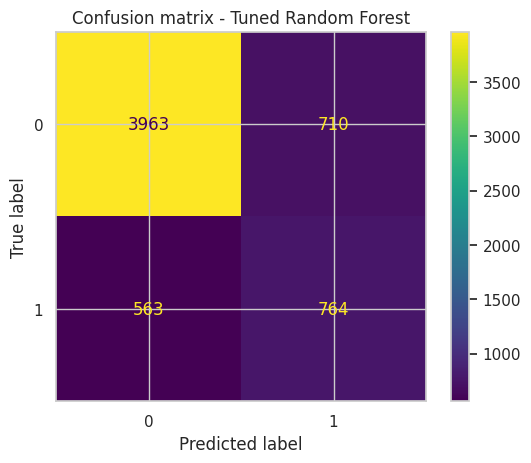


Cek konsistensi: best_score_ GridSearch = 0.5444 vs CV F1 evaluate() = 0.5444


,CV_F1,Test_Acc,Test_Prec,Test_Rec,Test_F1,CV_F1_std,Train_F1
Model,,,,,,,
Random Forest,0.4781,0.8113,0.6275,0.3617,0.4589,0.0064,0.9988
Tuned Random Forest,0.5444,0.7878,0.5183,0.5757,0.5455,0.0048,0.6205


Selisih (sesudah - sebelum tuning):


,CV_F1,Test_Acc,Test_Prec,Test_Rec,Test_F1,Train_F1
Model,,,,,,
Tuned Random Forest,0.0663,-0.0235,-0.1091,0.214,0.0866,-0.3783


INTERPRETASI EXPERIMENT 4
- Hyperparameter terbaik: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
- Best CV F1 = 0.5444. Sebelum tuning CV F1 = 0.4781, sesudah = 0.5444 (selisih +0.0663; std CV = 0.0064).
- Test: Accuracy 0.8113 -> 0.7878; Precision 0.6275 -> 0.5183; Recall 0.3617 -> 0.5757; F1 0.4589 -> 0.5455 (selisih +0.0866).
- Train F1 0.9988 -> 0.6205 (gap train-test 0.5399 -> 0.0750).
- KESIMPULAN: YA, tuning meningkatkan performa secara berarti.
- Catatan: class_weight='balanced' terpilih, sehingga perubahan umumnya berupa Recall naik dengan Precision/Accuracy turun (pergeseran trade-off, bukan sekadar model 'lebih pintar').


In [ ]:
tuned = evaluate(grid.best_estimator_, f"Tuned {best3}", 4)
fitted["4"] = tuned
K3 = f"3|{best3}"
K4 = f"4|Tuned {best3}"

rb, rt = results[K3], results[K4]
print(f"\nCek konsistensi: best_score_ GridSearch = {grid.best_score_:.4f} vs CV F1 evaluate() = {rt['CV_F1']:.4f}")

ba = pd.DataFrame([rb, rt]).set_index("Model")
display(ba[metric_cols + ["CV_F1_std", "Train_F1"]].round(4))
print("Selisih (sesudah - sebelum tuning):")
display(ba[metric_cols + ["Train_F1"]].diff().iloc[[1]].round(4))

tol = max(rb["CV_F1_std"], rt["CV_F1_std"])
d_cv, d_te = rt["CV_F1"] - rb["CV_F1"], rt["Test_F1"] - rb["Test_F1"]
print("INTERPRETASI EXPERIMENT 4")
print(f"- Hyperparameter terbaik: {grid.best_params_}")
print(f"- Best CV F1 = {grid.best_score_:.4f}. Sebelum tuning CV F1 = {rb['CV_F1']:.4f}, sesudah = {rt['CV_F1']:.4f} (selisih {d_cv:+.4f}; std CV = {tol:.4f}).")
print(f"- Test: Accuracy {rb['Test_Acc']:.4f} -> {rt['Test_Acc']:.4f}; Precision {rb['Test_Prec']:.4f} -> {rt['Test_Prec']:.4f}; "
      f"Recall {rb['Test_Rec']:.4f} -> {rt['Test_Rec']:.4f}; F1 {rb['Test_F1']:.4f} -> {rt['Test_F1']:.4f} (selisih {d_te:+.4f}).")
print(f"- Train F1 {rb['Train_F1']:.4f} -> {rt['Train_F1']:.4f} (gap train-test {rb['Train_F1']-rb['Test_F1']:.4f} -> {rt['Train_F1']-rt['Test_F1']:.4f}).")
if d_cv > tol and d_te > 0:
    v = "YA, tuning meningkatkan performa secara berarti."
elif d_cv > 0 and d_te > 0:
    v = "Tuning memberi peningkatan KECIL; selisihnya masih dalam kisaran variasi antar fold, jadi dampaknya terbatas."
else:
    v = "TIDAK, tuning tidak meningkatkan performa pada test set."
print("- KESIMPULAN:", v)
if grid.best_params_.get("model__class_weight") == "balanced":
    print("- Catatan: class_weight='balanced' terpilih, sehingga perubahan umumnya berupa Recall naik dengan Precision/Accuracy turun (pergeseran trade-off, bukan sekadar model 'lebih pintar').")

**Analisis Hasil Evaluasi model setelah tuning (sebelum vs sesudah)**

| | CV F1 | Test Acc | Test Prec | Test Rec | Test F1 | Train F1 |
|---|---|---|---|---|---|---|
| Sebelum tuning (RF default) | 0,4781 | 0,8113 | 0,6275 | 0,3617 | 0,4589 | 0,9988 |
| Sesudah tuning | **0,5444** | 0,7878 | 0,5183 | 0,5757 | **0,5455** | 0,6205 |
| Selisih | +0,0663 | -0,0235 | -0,1091 | +0,2140 | +0,0866 | -0,3783 |

- Hyperparameter tuning meningkatkan performa model. Test F1 naik 0,0866 dan CV F1 naik 0,0663, jauh lebih besar daripada simpangan baku CV (sekitar 0,005 sampai 0,006).
- Peningkatan berasal dari dua hal: (1) `class_weight='balanced'` menggeser keseimbangan prediksi sehingga Recall naik dari 0,36 menjadi 0,58, dengan konsekuensi Precision dan Accuracy turun; (2) pembatasan `max_depth` dan `min_samples_leaf` mengurangi overfitting (gap Train F1 dan Test F1 turun dari 0,54 menjadi 0,075).
- Penurunan Accuracy tidak berarti model memburuk, karena metrik utama adalah F1 dan model kini jauh lebih banyak menangkap nasabah default: pada *confusion matrix* test, nasabah default yang terdeteksi (*true positive*) berjumlah 764 dan yang terlewat 563, dibandingkan baseline Experiment 1 yang hanya mendeteksi 355 dan melewatkan 972; harga yang dibayar adalah alarm palsu sebanyak 710 (baseline hanya 179).
- Test F1 (0,5455) hampir sama dengan CV F1 (0,5444) dan `best_score_` GridSearch sama dengan CV F1 hasil evaluasi ulang (0,5444). Ini menunjukkan hasil konsisten dan tidak ada indikasi data leakage.

---
# 8. Experiment 5 — Advanced Model

Memakai metode boosting yang lebih advanced, di sini XGBoost (gradient boosting yang membangun pohon secara berurutan, tiap pohon memperbaiki kesalahan pohon sebelumnya) lalu membandingkannya dengan model terbaik Experiment 4.

jika model tuned di Experiment 4 memakai `class_weight="balanced"`, XGBoost diberi bobot kelas setara lewat `scale_pos_weight` (rasio kelas negatif/positif pada training set). Tanpa itu, perbedaan F1 bisa berasal dari trade-off Precision/Recall, bukan dari kualitas algoritmanya.


scale_pos_weight dipakai: 3.521
=== XGBoost (Experiment 5) ===
5-fold CV (train): Acc 0.7640 | Prec 0.4746 | Rec 0.6257 | F1 0.5398 (std 0.0067)
Test set         : Acc 0.7637 | Prec 0.4738 | Rec 0.6202 | F1 0.5372
Train F1 (cek overfitting): 0.5895


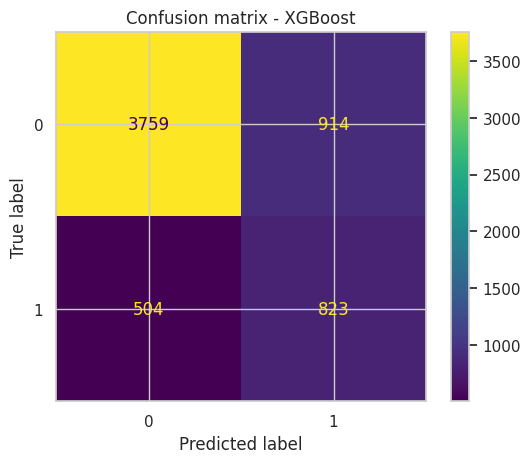

In [ ]:
use_weight = grid.best_params_.get("model__class_weight") == "balanced"
spw = float((y_train == 0).sum() / (y_train == 1).sum()) if use_weight else 1.0
print("scale_pos_weight dipakai:", round(spw, 3))

xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, eval_metric="logloss", random_state=RANDOM_STATE,
)
adv = evaluate(make_pipe(xgb), "XGBoost", 5)
fitted["5"] = adv
K5 = "5|XGBoost"

**Metode advanced kedua: Gradient Boosting scikit-learn.** Satu metode advanced sudah memenuhi syarat dosen; sel ini hanya memperkaya pembahasan. Hasilnya berlabel "5b" dan **tidak masuk tabel ringkasan resmi**.

=== Gradient Boosting (sklearn) (Experiment 5b) ===
5-fold CV (train): Acc 0.8220 | Prec 0.6791 | Rec 0.3707 | F1 0.4795 (std 0.0075)
Test set         : Acc 0.8185 | Prec 0.6662 | Rec 0.3595 | F1 0.4670
Train F1 (cek overfitting): 0.4943


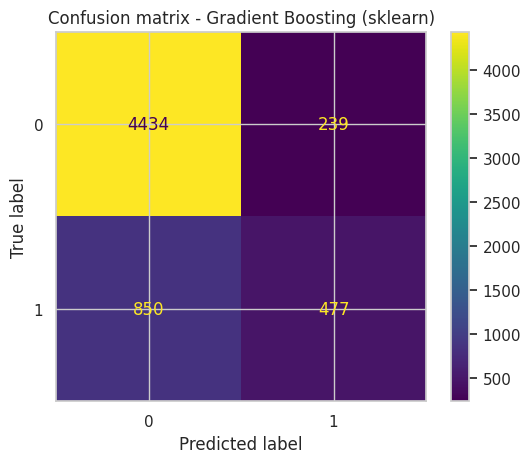

In [ ]:
gb = evaluate(make_pipe(GradientBoostingClassifier(random_state=RANDOM_STATE)),
              "Gradient Boosting (sklearn)", "5b")

**Analisis Hasil Experiment 5b (Gradient Boosting scikit-learn, tambahan)**

Tanpa pembobotan kelas, Gradient Boosting menghasilkan CV F1 0,4795 dan Test F1 0,4670 (Recall hanya 0,3595), hampir sama dengan Random Forest default. Hasil ini tidak masuk tabel resmi, tetapi memperkuat temuan bahwa pembobotan kelas lebih berpengaruh terhadap F1 daripada kompleksitas algoritma.

Membandingkan XGBoost (Experiment 5) dengan model terbaik Experiment 4 pada kelima metrik, lalu menyimpulkan apakah model advanced lebih baik. Kriteria yang sama: selisih dianggap berarti hanya jika melebihi simpangan baku CV. Sesuai catatan dosen, model yang lebih kompleks tidak otomatis lebih baik.

In [ ]:
r4, r5 = results[K4], results[K5]
c45 = pd.DataFrame([r4, r5]).set_index("Model")
display(c45[metric_cols + ["CV_F1_std", "Train_F1"]].round(4))
print("Selisih (Experiment 5 - Experiment 4):")
display(c45[metric_cols].diff().iloc[[1]].round(4))

tol = max(r4["CV_F1_std"], r5["CV_F1_std"])
d_cv, d_te = r5["CV_F1"] - r4["CV_F1"], r5["Test_F1"] - r4["Test_F1"]
print("INTERPRETASI EXPERIMENT 5")
print(f"- CV F1: {r4['CV_F1']:.4f} (Tuned {best3}) vs {r5['CV_F1']:.4f} (XGBoost), selisih {d_cv:+.4f}; std CV = {tol:.4f}.")
print(f"- Test F1: {r4['Test_F1']:.4f} vs {r5['Test_F1']:.4f}, selisih {d_te:+.4f}.")
print(f"- Precision {r4['Test_Prec']:.4f} vs {r5['Test_Prec']:.4f}; Recall {r4['Test_Rec']:.4f} vs {r5['Test_Rec']:.4f}; Accuracy {r4['Test_Acc']:.4f} vs {r5['Test_Acc']:.4f}.")
if d_cv > tol and d_te > 0:
    v5 = "YA, model advanced memberi performa lebih baik secara berarti."
elif abs(d_cv) <= tol:
    v5 = "Tidak ada perbedaan yang berarti (selisih dalam variasi antar fold); model yang lebih sederhana patut dipertimbangkan."
else:
    v5 = "TIDAK, model advanced tidak lebih baik daripada model terbaik Experiment 4."
print("- KESIMPULAN:", v5)
print(f"- Gap train-test: {best3} tuned {r4['Train_F1']-r4['Test_F1']:.4f} vs XGBoost {r5['Train_F1']-r5['Test_F1']:.4f}.")

,CV_F1,Test_Acc,Test_Prec,Test_Rec,Test_F1,CV_F1_std,Train_F1
Model,,,,,,,
Tuned Random Forest,0.5444,0.7878,0.5183,0.5757,0.5455,0.0048,0.6205
XGBoost,0.5398,0.7637,0.4738,0.6202,0.5372,0.0067,0.5895


Selisih (Experiment 5 - Experiment 4):


,CV_F1,Test_Acc,Test_Prec,Test_Rec,Test_F1
Model,,,,,
XGBoost,-0.0046,-0.0242,-0.0445,0.0445,-0.0083


INTERPRETASI EXPERIMENT 5
- CV F1: 0.5444 (Tuned Random Forest) vs 0.5398 (XGBoost), selisih -0.0046; std CV = 0.0067.
- Test F1: 0.5455 vs 0.5372, selisih -0.0083.
- Precision 0.5183 vs 0.4738; Recall 0.5757 vs 0.6202; Accuracy 0.7878 vs 0.7637.
- KESIMPULAN: Tidak ada perbedaan yang berarti (selisih dalam variasi antar fold); model yang lebih sederhana patut dipertimbangkan.
- Gap train-test: Random Forest tuned 0.0750 vs XGBoost 0.0523.


**Analisis Hasil Experiment 5 (Advanced Model: XGBoost)**

`scale_pos_weight = 3,521` adalah rasio kelas negatif terhadap positif pada data latih (23.364 : 6.636 pada seluruh data), disetel agar setara dengan `class_weight='balanced'` sehingga perbandingan dengan Random Forest tuned adil.

| | CV F1 (std) | Test Acc | Test Prec | Test Rec | Test F1 | Train F1 |
|---|---|---|---|---|---|---|
| Random Forest tuned (Exp 4) | 0,5444 (0,0048) | 0,7878 | 0,5183 | 0,5757 | 0,5455 | 0,6205 |
| XGBoost (Exp 5) | 0,5398 (0,0067) | 0,7637 | 0,4738 | 0,6202 | 0,5372 | 0,5895 |
| Selisih | -0,0046 | -0,0242 | -0,0445 | +0,0445 | -0,0083 | |

- Model advanced tidak memberikan performa yang lebih baik. Selisih CV F1 (-0,0046) lebih kecil daripada simpangan baku (0,0067), sehingga kedua model praktis setara; Test F1 XGBoost bahkan sedikit lebih rendah (0,5372 vs 0,5455).
- XGBoost memiliki Recall lebih tinggi (0,6202) tetapi Precision dan Accuracy lebih rendah, sehingga perbedaannya lebih berupa pergeseran trade-off daripada peningkatan kualitas.
- XGBoost tidak overfitting (gap Train-Test F1 sekitar 0,05).
- Keterbatasan: XGBoost hanya diuji dengan satu konfigurasi tanpa hyperparameter tuning, sedangkan Random Forest sudah dituning dengan GridSearchCV. Dengan tuning, hasilnya mungkin dapat meningkat. Kesimpulan ini sejalan dengan catatan soal bahwa model yang lebih kompleks tidak selalu lebih baik.

---
# 9. Final Analysis

## 9.1 Tabel ringkasan seluruh eksperimen

Sel berikut menyusun tabel persis sesuai format Bagian E.1 dosen (Experiment, Model, CV F1, Test Accuracy, Precision, Recall, F1) langsung dari dictionary `results`, sehingga angkanya otomatis sama dengan hasil di notebook. Juga disimpan ke `summary_experiments.csv` untuk disalin ke PDF.

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1,Baseline (Logistic Regression),0.3367,0.8082,0.6648,0.2675,0.3815
1,2,Baseline + Preprocessing,0.3641,0.8088,0.6923,0.2442,0.3610
2,3,Model Comparison (terbaik: Random Forest),0.4781,0.8113,0.6275,0.3617,0.4589
3,4,Tuned Model (Random Forest),0.5444,0.7878,0.5183,0.5757,0.5455
4,5,Advanced Model (XGBoost),0.5398,0.7637,0.4738,0.6202,0.5372


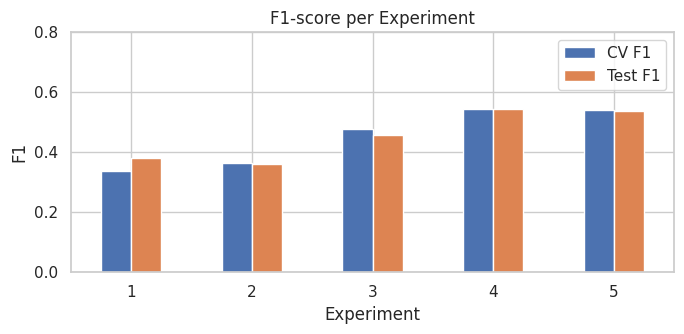

In [ ]:
rows = [
    ("1", "Baseline (Logistic Regression)",         results[K1]),
    ("2", "Baseline + Preprocessing",               results[K2]),
    ("3", f"Model Comparison (terbaik: {best3})",   results[K3]),
    ("4", f"Tuned Model ({best3})",                 results[K4]),
    ("5", "Advanced Model (XGBoost)",               results[K5]),
]
summary = pd.DataFrame([{
    "Experiment": e, "Model": m, "CV F1": r["CV_F1"],
    "Test Accuracy": r["Test_Acc"], "Test Precision": r["Test_Prec"],
    "Test Recall": r["Test_Rec"], "Test F1": r["Test_F1"],
} for e, m, r in rows]).round(4)

display(summary)
summary.to_csv("summary_experiments.csv", index=False)
comp3[metric_cols].round(4).to_csv("experiment3_comparison.csv")

summary.set_index("Experiment")[["CV F1", "Test F1"]].plot.bar(figsize=(7, 3.5), title="F1-score per Experiment")
plt.ylabel("F1"); plt.xticks(rotation=0); plt.ylim(0, max(0.8, float(summary["CV F1"].max()) + 0.1))
plt.tight_layout(); plt.show()

**Analisis Hasil Tabel ringkasan seluruh eksperimen**

Tabel di atas adalah ringkasan yang diambil langsung dari hasil eksperimen sehingga angkanya sama dengan output setiap eksperimen di notebook. Tren yang terlihat:

1. F1 test naik dari 0,3815 (baseline) hingga 0,5455 (Random Forest tuned), sedangkan CV F1 naik dari 0,3367 menjadi 0,5444.
2. Lompatan terbesar terjadi pada pergantian ke Random Forest (Exp 3) dan pada tuning dengan pembobotan kelas (Exp 4); preprocessing (Exp 2) dan model advanced (Exp 5) tidak memberi peningkatan berarti.
3. Accuracy justru tertinggi pada Exp 1 sampai 3 (sekitar 0,81) dan menurun pada Exp 4 dan 5, karena model dirancang untuk menaikkan Recall pada kelas default. Ini menunjukkan Accuracy menyesatkan pada data tidak seimbang.

## 9.2 Rekomendasi model final

**Sel berikut:** memberi **rekomendasi** model final dengan aturan eksplisit: (1) ambil model dengan CV F1 tertinggi; (2) jika ada model yang lebih sederhana dengan CV F1 dalam batas satu simpangan baku dari yang tertinggi, pilih yang lebih sederhana (prinsip *parsimony*, sesuai catatan dosen bahwa model final tidak harus paling kompleks); (3) verifikasi dengan Test F1 dan gap overfitting. Ini hanya rekomendasi: **keputusan akhir dan alasannya tetap harus kamu tulis sendiri** di PDF.

In [ ]:
cand = [
    ("1", "Baseline Logistic Regression",        results[K1]),
    ("2", "Logistic Regression + Preprocessing", results[K2]),
    ("3", f"{best3} (default)",                  results[K3]),
    ("4", f"Tuned {best3}",                      results[K4]),
    ("5", "XGBoost",                             results[K5]),
]
top = max(cand, key=lambda t: t[2]["CV_F1"])
band = top[2]["CV_F1"] - top[2]["CV_F1_std"]
within = [c for c in cand if c[2]["CV_F1"] >= band]
reco = within[0]          # urutan list = urutan kompleksitas kasar (sederhana -> kompleks)
print("Kandidat dalam batas 1 std dari CV F1 tertinggi:", [c[1] for c in within])
print(f"CV F1 tertinggi: {top[1]} ({top[2]['CV_F1']:.4f})")
print(f"\n>>> REKOMENDASI MODEL FINAL: Experiment {reco[0]} - {reco[1]}")
r = reco[2]
print(f"    CV F1 {r['CV_F1']:.4f} | Test F1 {r['Test_F1']:.4f} | Acc {r['Test_Acc']:.4f} | "
      f"Prec {r['Test_Prec']:.4f} | Rec {r['Test_Rec']:.4f} | gap train-test {r['Train_F1']-r['Test_F1']:.4f}")
final_key = reco[0]

Kandidat dalam batas 1 std dari CV F1 tertinggi: ['Tuned Random Forest', 'XGBoost']
CV F1 tertinggi: Tuned Random Forest (0.5444)

>>> REKOMENDASI MODEL FINAL: Experiment 4 - Tuned Random Forest
    CV F1 0.5444 | Test F1 0.5455 | Acc 0.7878 | Prec 0.5183 | Rec 0.5757 | gap train-test 0.0750


**Analisis Hasil Rekomendasi model final**

Dua model berada dalam batas satu simpangan baku dari CV F1 tertinggi: Random Forest tuned dan XGBoost. Random Forest tuned dipilih sebagai model final karena (1) CV F1 dan Test F1 tertinggi (0,5444 dan 0,5455), walaupun selisihnya kecil; (2) hasil CV dan test sangat konsisten sehingga estimasi performanya dapat dipercaya; (3) tidak overfitting berat (gap 0,075) setelah tuning; dan (4) Precision (0,5183) dan Accuracy (0,7878) lebih tinggi daripada XGBoost. Jika biaya kegagalan mendeteksi nasabah default dianggap jauh lebih besar daripada alarm palsu, XGBoost (Recall 0,6202) dapat dipertimbangkan sebagai alternatif.

## 9.3 Fitur paling berpengaruh pada model final

Menampilkan 10 fitur terpenting model final (`feature_importances_` untuk model berbasis pohon, koefisien untuk Logistic Regression). Hasil ini opsional tetapi memperkuat justifikasi model final dengan wawasan bisnis (misalnya riwayat keterlambatan `PAY_0` biasanya paling menentukan).

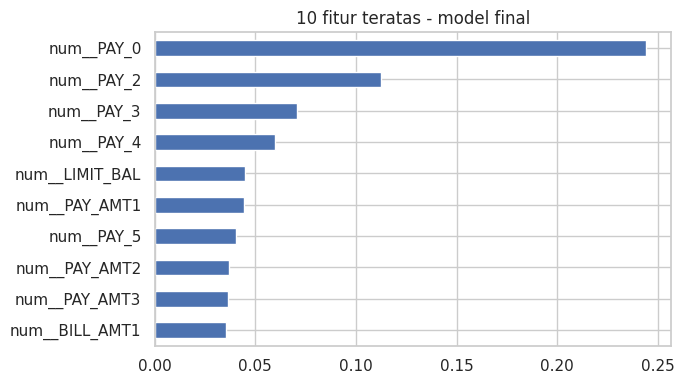

num__PAY_0        0.2444
num__PAY_2        0.1124
num__PAY_3        0.0706
num__PAY_4        0.0600
num__LIMIT_BAL    0.0446
num__PAY_AMT1     0.0443
num__PAY_5        0.0403
num__PAY_AMT2     0.0369
num__PAY_AMT3     0.0366
num__BILL_AMT1    0.0354


In [ ]:
final_model = fitted[final_key]
if hasattr(final_model, "named_steps") and "prep" in final_model.named_steps:
    names = final_model.named_steps["prep"].get_feature_names_out()
    est = final_model.named_steps["model"]
else:
    names, est = np.array(X.columns), final_model

if hasattr(est, "feature_importances_"):
    imp = pd.Series(est.feature_importances_, index=names)
else:
    imp = pd.Series(est.coef_[0], index=names)

top10 = imp.reindex(imp.abs().sort_values(ascending=False).index).head(10)
top10.plot.barh(figsize=(7, 4), title="10 fitur teratas - model final").invert_yaxis()
plt.tight_layout(); plt.show()
print(top10.round(4).to_string())

**Analisis Hasil Fitur paling berpengaruh pada model final**

`PAY_0` (status pembayaran bulan terakhir) adalah fitur terpenting dengan skor 0,2444, jauh di atas fitur lainnya, diikuti `PAY_2` (0,1124), `PAY_3` (0,0706), dan `PAY_4` (0,0600). Riwayat keterlambatan pembayaran terutama pada bulan-bulan terakhir paling menentukan risiko default, sejalan dengan hasil korelasi pada tahap eksplorasi (`PAY_0` memiliki korelasi tertinggi, 0,325). `LIMIT_BAL` (0,0446) berada di urutan kelima. Catatan: *feature importance* Random Forest cenderung membesarkan fitur kontinu bernilai banyak seperti `BILL_AMT` dan `PAY_AMT`, sehingga urutan di bawah `PAY_*` sebaiknya tidak ditafsirkan terlalu kuat.